In [45]:
import torch
import torchaudio
from pathlib import Path

In [46]:
datapath = Path.cwd().parent / "data"

In [47]:
waveform, sr = torchaudio.load(datapath / "reference.wav")

In [48]:
# full waveform
waveform.shape

torch.Size([1, 192000])

In [49]:
# sample rate / second
sr

24000

In [50]:
# duration
waveform.shape[-1] / sr

8.0

---


## Fourier Transforms


In [51]:
import numpy as np
import matplotlib.pyplot as plt

In [52]:
sr = 24000
duration = 1.0
freq = 440

In [53]:
tens = torch.ones(sr)
tens.shape

torch.Size([24000])

In [54]:
t = torch.arange(0, duration, 1 / sr)
t

tensor([0.0000e+00, 4.1667e-05, 8.3333e-05,  ..., 9.9988e-01, 9.9992e-01,
        9.9996e-01])

Raw range


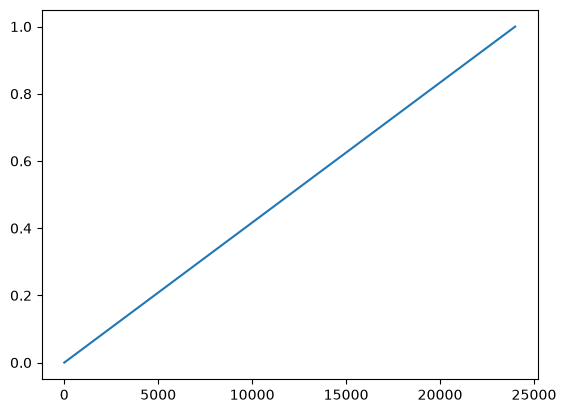

In [55]:
plt.plot(t)

In [56]:
signal = torch.sin(2 * torch.pi * freq * t)

In [57]:
signal.shape

torch.Size([24000])

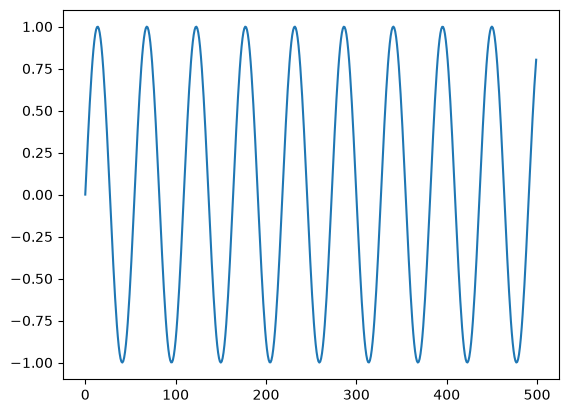

In [58]:
plt.plot(signal.numpy()[:500])

In [59]:
signal

tensor([ 0.0000,  0.1149,  0.2284,  ..., -0.3386, -0.2284, -0.1150])

In [60]:
from torch.fft import fft, fftfreq

In [61]:
fft_output = fft(signal)

In [62]:
# torch is using complex numbers to be compact, need to get abs to graph
magnitude = torch.abs(fft_output)

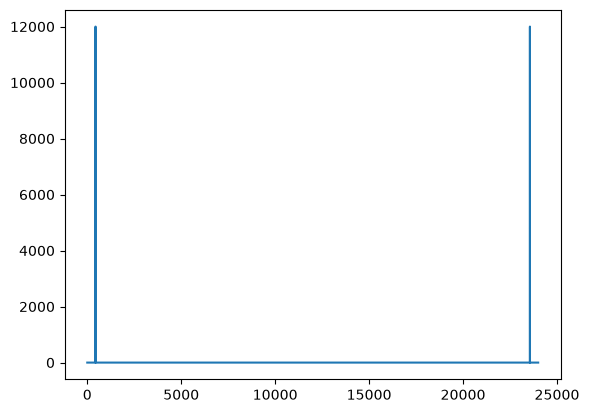

In [63]:
plt.plot(magnitude)

In [ ]:
freqs = fftfreq(len(signal), d=1 / sr)

In [ ]:
freqs

tensor([ 0.,  1.,  2.,  ..., -3., -2., -1.])

## FFT on single frequency


Spikes right at 440


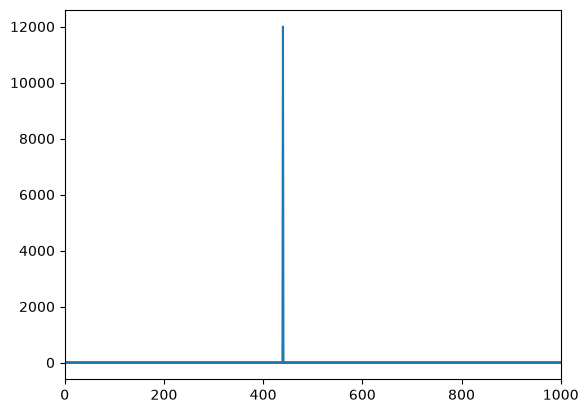

In [67]:
plt.plot(freqs, magnitude)
plt.xlim(0, 1000)
plt.show()

multiple frequencies


In [70]:
freq1 = 440
freq2 = 1000

signal2 = torch.sin(2 * torch.pi * freq1 * t) + torch.sin(2 * torch.pi * freq2 * t)

In [71]:
signal2

tensor([ 0.0000,  0.3738,  0.7284,  ..., -1.0454, -0.7281, -0.3735])

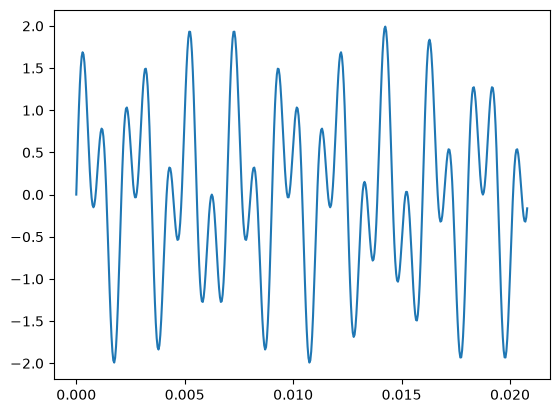

In [72]:
plt.plot(t[:500], signal2[:500])
plt.show()

In [ ]:
fft_output2 = fft(signal2)
magnitude2 = np.abs(fft_output2)
freqs2 = fftfreq(len(signal2), d=1 / sr)

/var/folders/l_/j4xz7cwj6vzb9bs_c9wxlch40000gn/T/ipykernel_94983/2996186008.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  magnitude2 = np.abs(fft_output2)


(0.0, 1500.0)

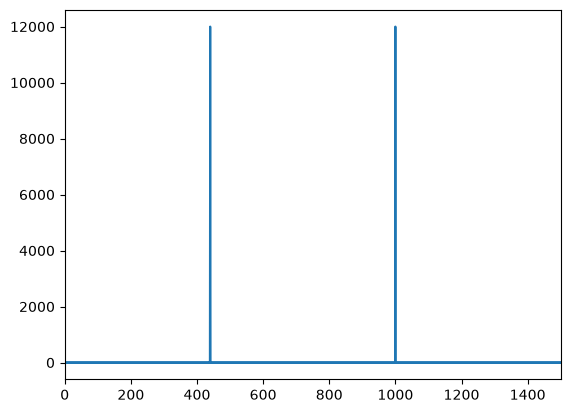

In [78]:
plt.plot(freqs2, magnitude2)
plt.xlim(0, 1500)